# ML Project - Linear Regression Insurance Prediction

## Import Libraries

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

## Import Data

In [5]:
pwd

'C:\\Users\\OM\\Projects'

In [6]:
cd C:\Users\OM\OneDrive\Desktop\Projects

C:\Users\OM\OneDrive\Desktop\Projects


In [7]:
data = pd.read_csv("ML Project - Linear Regression Insurance Prediction.txt")

In [8]:
data.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


## Find Null Values

In [9]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
data.isnull().any()

age         False
sex         False
bmi         False
children    False
smoker      False
region      False
charges     False
dtype: bool

In [11]:
# 0 Null Values

## Find and Drop Duplicate Values

In [12]:
data.duplicated().sum()

np.int64(1)

In [13]:
data.drop_duplicates(inplace=True)

In [14]:
data.duplicated().sum()

np.int64(0)

## Scatter Plot between Age and Children

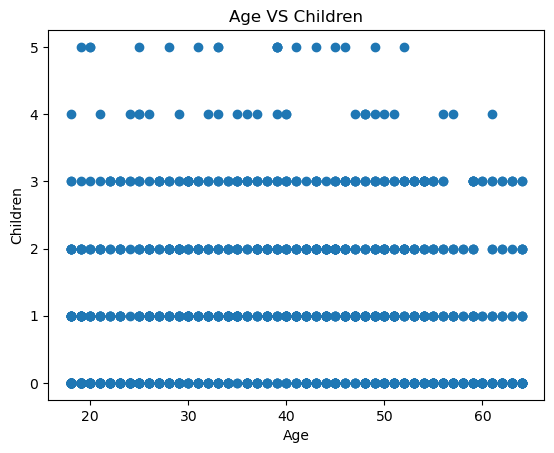

In [15]:
plt.scatter(data["age"],data["children"])
plt.xlabel("Age")
plt.ylabel("Children")
plt.title("Age VS Children");

## Bar Plot between BMI and Children

In [16]:
group_data = data.groupby("children")["bmi"].mean()

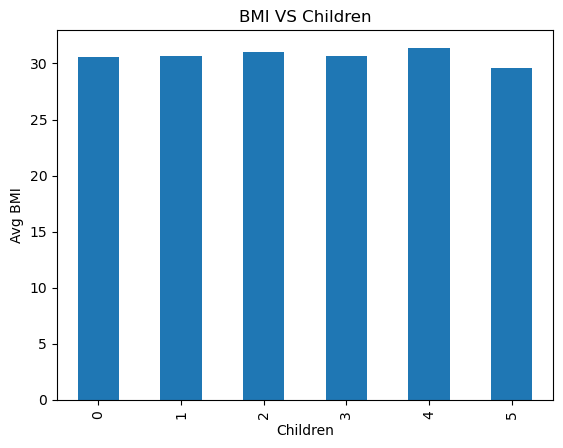

In [17]:
group_data.plot(kind="bar")
plt.xlabel("Children")
plt.ylabel("Avg BMI")
plt.title("BMI VS Children");

## Encoding

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [19]:
data = pd.get_dummies(data, drop_first=True)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   charges           1337 non-null   float64
 4   sex_male          1337 non-null   bool   
 5   smoker_yes        1337 non-null   bool   
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 58.8 KB


## Model

In [21]:
data

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


### Divide X and Y

In [22]:
x = data.drop(["charges"], axis=1)
y = data["charges"]

### Split Training and Testing 

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x, y, train_size=0.8, random_state=42)

### Scaling

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
x_train = pd.DataFrame(scaler.fit_transform(x_train))
x_test = pd.DataFrame(scaler.fit_transform(x_test))

### Model Evaluation

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
LR_model = LinearRegression()

In [30]:
LR_model.fit(x_train,y_train)

LinearRegression()

### Training and Testing Score

In [31]:
LR_model.score(x_train,y_train)

0.7299057809339075

In [32]:
LR_model.score(x_test,y_test)

0.7919143768498849

### Slope and Intercept

In [33]:
LR_model.coef_

array([3472.97555343, 1927.82825101,  636.5011853 ,  -50.74967467,
       9234.34248701, -168.94443943, -371.7808097 , -284.61039635])

In [34]:
LR_model.intercept_

np.float64(13030.203369289053)

### Mean Squared Error, Mean Absolute Error, Root mean Squared error and R2 score

In [35]:
LR_y_predict = LR_model.predict(x_test)

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

In [37]:
mean_squared_error(y_test,LR_y_predict)

38236995.09360463

In [38]:
mean_absolute_error(y_test,LR_y_predict)

4132.380119782653

In [39]:
root_mean_squared_error(y_test,LR_y_predict)

6183.606964677221

In [40]:
r2_score(y_test,LR_y_predict)

0.7919143768498849

## Random Forest

### Split for Random Forest

In [41]:
RF_x_train,RF_x_test,RF_y_train,RF_y_test = train_test_split(x, y, train_size=0.8, random_state=40)

### Model 

In [42]:
from sklearn.ensemble import RandomForestRegressor

In [43]:
RF_model = RandomForestRegressor(50)

In [44]:
RF_model.fit(RF_x_train,RF_y_train)

RandomForestRegressor(n_estimators=50)

### Training and Testing Score

In [45]:
RF_model.score(RF_x_train,RF_y_train)

0.9723434621742254

In [46]:
RF_model.score(RF_x_test,RF_y_test)

0.885178500573819

### Mean Squared Error, Mean Absolute Error, Root mean Squared error and R2 score

In [47]:
RF_y_predicted = RF_model.predict(RF_x_test)

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

In [49]:
mean_squared_error(RF_y_test,RF_y_predicted)

18382177.62920693

In [50]:
mean_absolute_error(RF_y_test,RF_y_predicted)

2314.8832750314687

In [51]:
root_mean_squared_error(RF_y_test,RF_y_predicted)

4287.444183800756

In [52]:
r2_score(RF_y_test,RF_y_predicted)

0.885178500573819